



##  Introducción del proyecto

El objetivo de este proyecto es desarrollar un modelo basado en redes neuronales recurrentes (RNN), específicamente de tipo **LSTM (Long Short-Term Memory)**, para predecir el rendimiento académico final de estudiantes en la materia de matemáticas. Para ello, se utilizó la base de datos **student-mat.csv**, que contiene información sobre el desempeño académico de estudiantes de secundaria en Portugal, junto con diversas variables sociales, personales y conductuales.

El rendimiento académico se mide a través de la variable `G3`, que representa la calificación final del estudiante en una escala de 0 a 20. Las variables disponibles incluyen notas anteriores (`G1` y `G2`)

La elección de un modelo LSTM se debe a su capacidad para capturar dependencias a largo plazo en secuencias temporales, lo cual resulta esencial para predecir el rendimiento de los estudiantes, ya que la calificación final puede depender de una serie de factores previos que tienen un impacto progresivo. Además, las variables de comportamiento, como el tiempo dedicado al estudio y la frecuencia de ausencias, añaden contexto valioso para mejorar las predicciones.

A lo largo del proyecto, se siguieron los siguientes pasos:
1. **Selección y preprocesamiento de datos**: Se identificaron las variables relevantes y se normalizaron utilizando **MinMaxScaler**.
2. **Transformación de datos para LSTM**: Los datos se estructuraron en secuencias temporales, integrando las variables de comportamiento para proporcionar un contexto adicional al modelo.
3. **Construcción y entrenamiento del modelo**: Se diseñó una red LSTM con múltiples capas y técnicas de regularización, como **Dropout** y **BatchNormalization**, para evitar el sobreajuste.
4. **Evaluación del modelo**: Se utilizaron métricas como el **MSE** y **R²** para evaluar el rendimiento del modelo.



-

In [130]:
import pandas as pd
import numpy as np


# Cargar los datos
mat_df = pd.read_csv("student-mat.csv", sep=';')
por_df = pd.read_csv("student-por.csv", sep=';')

# Combinar ambos conjuntos de datos
df = pd.concat([mat_df, por_df])

features = ['G1', 'G2']
target = 'G3'

# Opción: normalizar datos
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(df[features])
y = scaler.fit_transform(df[[target]])


In [132]:


# Cada ejemplo es una secuencia de longitud 2: [G1, G2] → predicción G3
X_seq = []
y_seq = []

for i in range(len(X)):
    X_seq.append([[X[i][0]], [X[i][1]]])  # formato (timesteps, features)
    y_seq.append(y[i])

X_seq = np.array(X_seq) 
y_seq = np.array(y_seq)


In [174]:
# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# Predicción
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [142]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

model = Sequential()

# Primera capa LSTM con normalización y dropout
model.add(LSTM(128, input_shape=(2, 1), return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Segunda LSTM con normalización y dropout
model.add(LSTM(64, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Tercera LSTM final (sin return_sequences)
model.add(LSTM(32))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Capa de salida
model.add(Dense(1))

# Compilar
model.compile(optimizer='adam', loss='mse')
model.summary()



C:\Users\celso\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_51 (LSTM)                  │ (None, 2, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 2, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_52 (LSTM)                  │ (None, 2, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 2, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_53 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,313 (505.13 KB)

 Trainable params: 128,865 (503.38 KB)

 Non-trainable params: 448 (1.75 KB)

In [140]:
print("X_seq shape:", X_seq.shape)  # → deberías ver (n_samples, 2, N)


X_seq shape: (1044, 2, 1)


In [144]:
model.fit(X_seq, y_seq, epochs=50, batch_size=8, validation_split=0.2)


Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 1.5706 - val_loss: 0.0498
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.7088 - val_loss: 0.0370
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.3856 - val_loss: 0.0381
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.3593 - val_loss: 0.0327
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2501 - val_loss: 0.0253
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2113 - val_loss: 0.0140
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1605 - val_loss: 0.0078
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1239 - val_loss: 0.0080
Epoch 9/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1067 - val_loss: 0.0181
Epoch 10/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0816 - val_loss: 0.0125
Epoch 11/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0697 - val_loss: 0.0101
Epoch 12/50
105/105 ━━━━━━━━━━━━━━━━━━━━

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


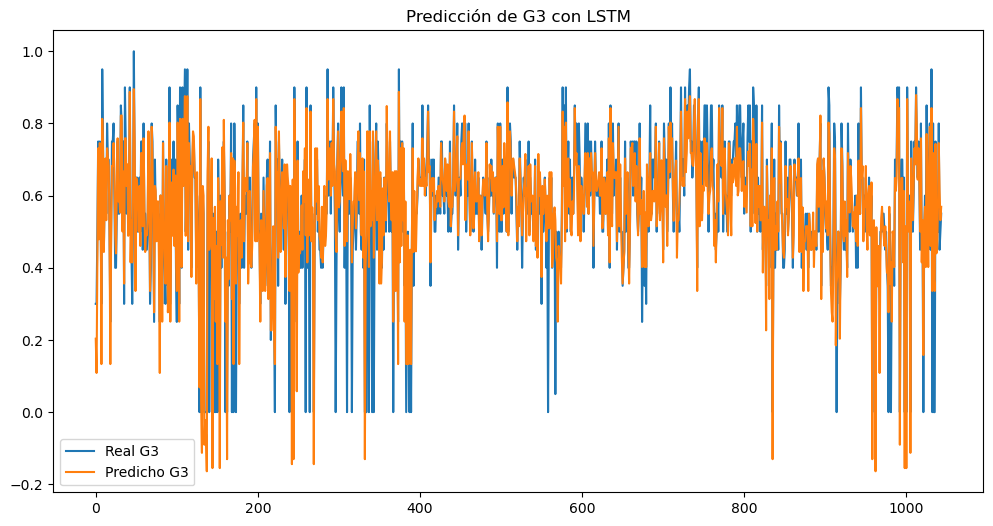

In [146]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6)) 
preds = model.predict(X_seq)
plt.plot(y_seq, label='Real G3')
plt.plot(preds, label='Predicho G3')
plt.legend()
plt.title('Predicción de G3 con LSTM')
plt.show()


In [178]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


y_test = y_test.reshape(-1)
y_pred = y_pred.reshape(-1)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Mostrar resultados
print("Evaluación del modelo")

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")



Evaluación del modelo
MSE:  0.0083
RMSE: 0.0913
MAE:  0.0549
R²:   0.7842
